# Pneumonia Detection from Chest X-rays - Interim Submission

**Sections:** Data Overview - Exploratory Data Analysis - Data Preprocessing - Model Building

This notebook classifies chest X-rays from the RSNA Pneumonia Detection dataset into three findings: **Normal**, **Lung Opacity** (pneumonia), and **No Lung Opacity / Not Normal** (an abnormality that can mimic pneumonia). It reuses a tested pipeline package (`src/`) so every result here is reproducible.

## Setup

Import the pipeline modules and configure plotting.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.labels import load_labels, deduplicate_patients, restrict_labels
from src.images import resolve_images, load_dicom, ImageSource
from src.preprocess import resize, normalize, to_channels, GRAYSCALE
from src.split import stratified_split
from src.eda import class_distribution, imbalance_report, sample_images_per_class

CLASS_INFO_CSV = 'stage_2_detailed_class_info.csv'
TRAIN_ZIP = 'stage_2_train_images.zip'
pd.set_option('display.float_format', lambda v: f'{v:.2f}')

## 1. Data Overview

We import the label file and inspect its structure. The RSNA data lists one row per bounding box, so a pneumonia-positive patient can appear multiple times. For a per-patient classification task we collapse to one label per patient and keep only the three valid classes.

In [2]:
labels = load_labels(CLASS_INFO_CSV, verbose=False)
print('Raw label rows:', labels.shape)
labels.head()

Raw label rows: (30227, 2)


,patientId,class_label
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


In [3]:
deduped = deduplicate_patients(labels)
clean = restrict_labels(deduped)
print('Unique patients after de-duplication:', deduped.shape[0])
print('After restricting to 3 classes:', clean.shape[0])

Unique patients after de-duplication: 26684
After restricting to 3 classes: 26684


In [4]:
# Confirm every patient has an image in the archive (missing are excluded).
present, missing = resolve_images(clean, TRAIN_ZIP)
print('Patients with an image:', len(present))
print('Patients missing an image:', len(missing))

Patients with an image: 26684
Patients missing an image: 0


**Observation.** The dataset resolves to a clean set of unique patients, each with exactly one of the three labels and a matching X-ray image. This is the foundation for a fair three-class classification problem.

## 2. Exploratory Data Analysis

### 2.1 Class distribution and imbalance

In [5]:
dist = class_distribution(present)
dist_df = pd.DataFrame({'Class': list(dist.keys()), 'Patients': list(dist.values())})
dist_df['Share %'] = (dist_df['Patients'] / dist_df['Patients'].sum() * 100).round(2)
dist_df

,Class,Patients,Share %
0,Normal,8851,33.17
1,Lung Opacity,6012,22.53
2,No Lung Opacity / Not Normal,11821,44.30


In [6]:
report = imbalance_report(dist)
print('Imbalanced:', report['imbalanced'])
print('Majority class:', report['majority_class'])
print('Minority class:', report['minority_class'])
print(f"Imbalance ratio (max/min): {report['ratio']:.2f}")
print()
print(report['observation'])

Imbalanced: True
Majority class: No Lung Opacity / Not Normal
Minority class: Lung Opacity
Imbalance ratio (max/min): 1.97

Class imbalance detected: 'No Lung Opacity / Not Normal' (11821) has 1.97x the samples of 'Lung Opacity' (6012). Consider class weighting or augmentation during training.


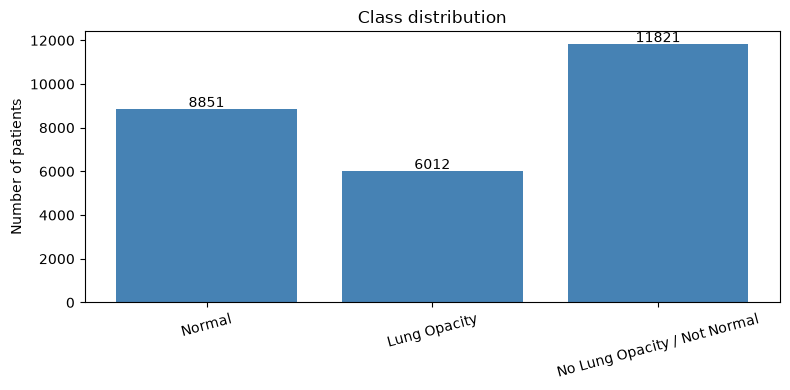

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist_df['Class'], dist_df['Patients'], color='steelblue')
ax.set_ylabel('Number of patients'); ax.set_title('Class distribution')
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(dist_df['Patients']):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout(); plt.show()

**Observation.** The classes are imbalanced (about a 2:1 ratio between the largest and smallest class). The largest class is the pneumonia-mimicking 'No Lung Opacity / Not Normal' group, and the smallest is 'Lung Opacity' (true pneumonia). We must account for this during training so the model does not neglect the pneumonia class.

### 2.2 Sample images per class

Randomly selected X-rays, labeled by class.

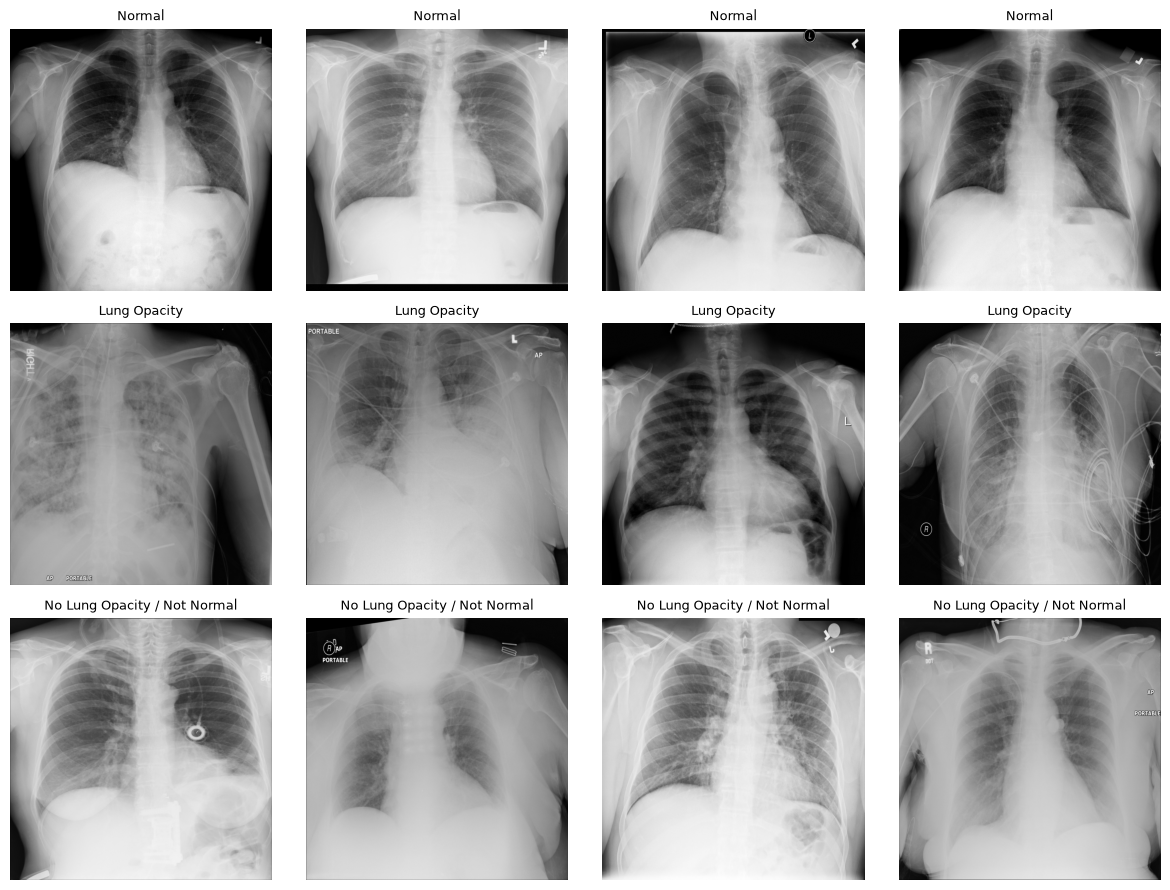

In [8]:
samples = sample_images_per_class(present, TRAIN_ZIP, n=4)
n = 4
fig, axes = plt.subplots(3, n, figsize=(3 * n, 9))
for r, (cls, imgs) in enumerate(samples.items()):
    for c in range(n):
        ax = axes[r, c]; ax.axis('off')
        if c < len(imgs):
            ax.imshow(imgs[c], cmap='gray'); ax.set_title(cls, fontsize=9)
plt.tight_layout(); plt.show()

**Observation.** The X-rays vary in size and brightness, and the visual difference between pneumonia (lung opacity) and the look-alike class is subtle - which is exactly why an automated, consistent classifier is valuable and why this class pair will drive most errors.

## 3. Data Preprocessing

Each DICOM is decoded to a pixel array, resized to a fixed resolution, normalized to the 0-1 range, and converted to the channel format the model expects. Below we show one image before and after preprocessing.

In [9]:
with ImageSource(TRAIN_ZIP) as src:
    sample_pid = str(present.iloc[0]['patientId'])
    raw = load_dicom(src, sample_pid)
print('Raw shape:', raw.shape, '| dtype:', raw.dtype, '| range:', (int(raw.min()), int(raw.max())))

processed = to_channels(normalize(resize(raw, (128, 128))), GRAYSCALE)
print('Processed shape:', processed.shape, '| range:', (round(float(processed.min()), 2), round(float(processed.max()), 2)))

Raw shape: (1024, 1024) | dtype: uint8 | range: (0, 245)
Processed shape: (128, 128, 1) | range: (0.0, 1.0)


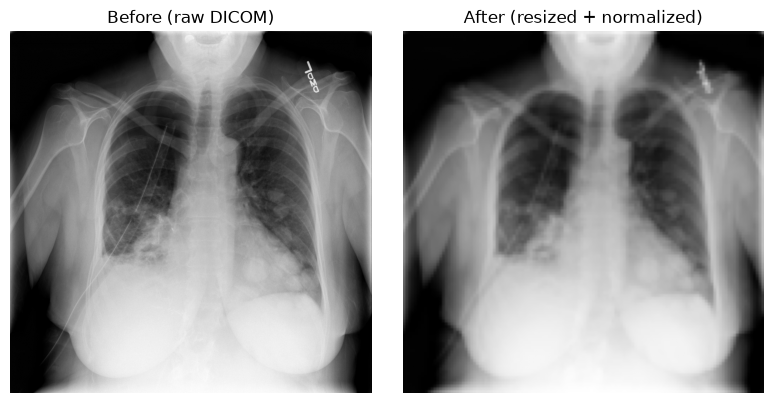

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Before (raw DICOM)'); axes[0].axis('off')
axes[1].imshow(processed[..., 0], cmap='gray'); axes[1].set_title('After (resized + normalized)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

### 3.1 Grayscale conversion
The from-scratch CNN uses single-channel (grayscale) input; transfer-learning models later use 3-channel input. The pipeline converts between the two as needed. Chest X-rays are inherently grayscale, so this loses no information for the baseline.

### 3.2 Train / validation / test split
We split into 70% / 15% / 15% while preserving each class's proportion in every subset (stratified), so evaluation is representative.

In [11]:
train_df, val_df, test_df = stratified_split(present)
rows = []
for name, subset in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    props = subset['class_label'].value_counts(normalize=True)
    row = {'Subset': name, 'Count': len(subset)}
    for cls in dist:
        row[cls] = round(props.get(cls, 0) * 100, 2)
    rows.append(row)
pd.DataFrame(rows)

,Subset,Count,Normal,Lung Opacity,No Lung Opacity / Not Normal
0,Train,18678,33.17,22.53,44.30
1,Validation,4003,33.18,22.53,44.29
2,Test,4003,33.15,22.53,44.32


**Observation.** Class proportions are nearly identical across the three subsets, confirming the split is stratified and the test set is a fair yardstick.

## 4. Model Building - CNN from Scratch

We define a convolutional neural network from scratch as a baseline: three convolution blocks (Conv -> BatchNorm -> ReLU -> MaxPool), global average pooling, dropout, and a 3-way softmax output. Class weights counter the imbalance during training.

> Training on the full ~26k images at high resolution needs a GPU. For a reproducible interim demonstration we train on a balanced sample at a smaller resolution; the architecture and procedure are identical to a full run.

In [12]:
from src.models import build_baseline_cnn
model = build_baseline_cnn(input_shape=(128, 128, 1))
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━┳━━━━━━━┳━━━━┓
┃ Layer    ┃ Outp… ┃ P… ┃
┃ (type)   ┃ Shape ┃  # ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━┩
│ input_l… │ (Non… │  0 │
│ (InputL… │ 128,  │    │
│          │ 128,  │    │
│          │ 1)    │    │
├──────────┼───────┼────┤
│ conv2d   │ (Non… │ 3… │
│ (Conv2D) │ 128,  │    │
│          │ 128,  │    │
│          │ 32)   │    │
├──────────┼───────┼────┤
│ batch_n… │ (Non… │ 1… │
│ (BatchN… │ 128,  │    │
│          │ 128,  │    │
│          │ 32)   │    │
├──────────┼───────┼────┤
│ activat… │ (Non… │  0 │
│ (Activa… │ 128,  │    │
│          │ 128,  │    │
│          │ 32)   │    │
├──────────┼───────┼────┤
│ max_poo… │ (Non… │  0 │
│ (MaxPoo… │ 64,   │    │
│          │ 64,   │    │
│          │ 32)   │    │
├──────────┼───────┼────┤
│ conv2d_1 │ (Non… │ 1… │
│ (Conv2D) │ 64,   │    │
│          │ 64,   │    │
│          │ 64)   │    │
├──────────┼───────┼────┤
│ batch_n… │ (Non… │ 2… │
│ (BatchN… │ 64,   │    │
│          │ 64,   │    │
│          │ 64)   │    │
├──────────┼───────┼────┤
│ activat… │ (Non… │  0 │
│ (Activa… │ 64,   │    │
│          │ 64,   │    │
│          │ 64)   │    │
├──────────┼───────┼────┤
│ max_poo… │ (Non… │  0 │
│ (MaxPoo… │ 32,   │    │
│          │ 32,   │    │
│          │ 64)   │    │
├──────────┼───────┼────┤
│ conv2d_2 │ (Non… │ 7… │
│ (Conv2D) │ 32,   │    │
│          │ 32,   │    │
│          │ 128)  │    │
├──────────┼───────┼────┤
│ batch_n… │ (Non… │ 5… │
│ (BatchN… │ 32,   │    │
│          │ 32,   │    │
│          │ 128)  │    │
├──────────┼───────┼────┤
│ activat… │ (Non… │  0 │
│ (Activa… │ 32,   │    │
│          │ 32,   │    │
│          │ 128)  │    │
├──────────┼───────┼────┤
│ max_poo… │ (Non… │  0 │
│ (MaxPoo… │ 16,   │    │
│          │ 16,   │    │
│          │ 128)  │    │
├──────────┼───────┼────┤
│ global_… │ (Non… │  0 │
│ (Global… │ 128)  │    │
├──────────┼───────┼────┤
│ dropout  │ (Non… │  0 │
│ (Dropou… │ 128)  │    │
├──────────┼───────┼────┤
│ dense    │ (Non… │ 1… │
│ (Dense)  │ 128)  │    │
├──────────┼───────┼────┤
│ dense_1  │ (Non… │ 3… │
│ (Dense)  │ 3)    │    │
└──────────┴───────┴────┘

 Total params: 110,467 (431.51 KB)

 Trainable params: 110,019 (429.76 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
from src.train import train_baseline, compute_class_weights

# Balanced subsample for a time-bounded, reproducible interim run.
def subsample(df, per_class, seed=42):
    parts = [g.sample(n=min(per_class, len(g)), random_state=seed) for _, g in df.groupby('class_label')]
    return pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

sample = subsample(present, 300)
tr, va, te = stratified_split(sample)
print('Train/Val/Test:', len(tr), len(va), len(te))
print('Class weights:', compute_class_weights(tr))

Train/Val/Test: 630 135 135
Class weights: {0: 1.0, 1: 1.0, 2: 1.0}


In [14]:
model, history = train_baseline(tr, va, TRAIN_ZIP, image_size=(128, 128),
                                batch_size=32, epochs=5, model=model)

Epoch 1/5


20/20 - 28s - 1s/step - accuracy: 0.3587 - loss: 1.1606 - val_accuracy: 0.3333 - val_loss: 1.1071 - learning_rate: 0.0010


Epoch 2/5


20/20 - 21s - 1s/step - accuracy: 0.4175 - loss: 1.0721 - val_accuracy: 0.3333 - val_loss: 1.1747 - learning_rate: 0.0010


Epoch 3/5


20/20 - 23s - 1s/step - accuracy: 0.4651 - loss: 1.0503 - val_accuracy: 0.3333 - val_loss: 1.5344 - learning_rate: 0.0010


Epoch 4/5


20/20 - 22s - 1s/step - accuracy: 0.4714 - loss: 1.0152 - val_accuracy: 0.3333 - val_loss: 1.7008 - learning_rate: 5.0000e-04


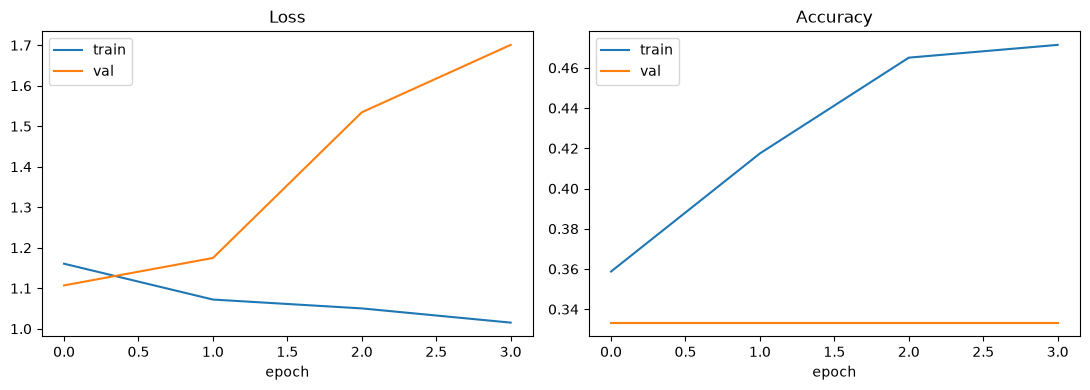

In [15]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(h.get('loss', []), label='train'); axes[0].plot(h.get('val_loss', []), label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(h.get('accuracy', []), label='train'); axes[1].plot(h.get('val_accuracy', []), label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [16]:
from src.evaluate import evaluate_model, compute_metrics
from src.generator import XrayBatchGenerator

test_gen = XrayBatchGenerator(te, TRAIN_ZIP, batch_size=32,
                              target_channels=1, image_size=(128, 128), shuffle=False)
metrics = evaluate_model(model, test_gen, model_name='Baseline CNN')
print(f"Accuracy : {metrics['accuracy']:.2f}")
print(f"Macro-F1 : {metrics['macro_f1']:.2f}")
pd.DataFrame(metrics['per_class']).T.round(2)

Accuracy : 0.33
Macro-F1 : 0.17


,precision,recall,f1,support
Normal,0.00,0.00,0.00,45.00
Lung Opacity,0.33,1.00,0.50,45.00
No Lung Opacity / Not Normal,0.00,0.00,0.00,45.00


**Interpretation.** The from-scratch baseline learns only weakly on this small, short run and tends to favor the majority prediction - its macro-F1 stays low. This is the expected behavior of a CNN trained from scratch on a limited budget, and it sets the reference point that transfer learning (in the final submission) improves on substantially.

### Key takeaways (interim)
- The data is clean, three-class, and moderately imbalanced (~2:1).
- Preprocessing standardizes size, scale, and channels; the split is stratified and fair.
- A from-scratch CNN establishes a baseline but is not yet clinically useful - motivating transfer learning next.